In [1]:
import os
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
import pyranges as pr

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
BENCH_DIR = "/home/dnanexus/data_dir/other_benchmarks"
# BENCH_DIR = "/s/project/deeprvat/ukb_gym/other_benchmarks"

!mkdir -p {BENCH_DIR}

In [ ]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


# UKBBGym

In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

mac = 20

consequence_columns = [c for c in anno.collect_schema().names() if c.startswith("consequence_")]
encode_columns = [c for c in anno.collect_schema().names() if c.startswith("encode_")]

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
    )
    .with_columns(
        aa_pos = pl.col('protein_position').str.split("/").list.get(0),
        ref_aa = pl.col('amino_acids').str.split("/").list.get(0, null_on_oob=True),
        alt_aa = pl.col('amino_acids').str.split("/").list.get(1, null_on_oob=True),
    )
    .select([
        'chrom', 
        'pos', 
        'ref', 
        'alt',
        'id', 
        'region',
        'aa_pos',
        'ref_aa',
        'alt_aa',
        'loftee_hc',
        'loftee_lc',
    ]
    + consequence_columns
    + encode_columns
    )
    .unique()
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_85378/3552699069.py:43: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


chrom,pos,ref,alt,id,region,aa_pos,ref_aa,alt_aa,loftee_hc,loftee_lc,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_incomplete_terminal_codon_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intron_variant,consequence_missense_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,consequence_synonymous_variant,consequence_upstream_gene_variant,encode_dels,encode_ca-ctcf,encode_ca,encode_ca-h3k4me3,encode_tf,encode_ca-tf,encode_pels,encode_pls
str,i64,str,str,str,str,str,str,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,bool,bool,bool,bool,bool,bool,bool,bool
"""chr7""",81713475,"""G""","""A""","""chr7:81713475:G:A""","""ENSG00000019991""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false
"""chr17""",5025801,"""CAG""","""C""","""chr17:5025801:CAG:C""","""ENSG00000129250""",null,null,null,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false
"""chr6""",111333089,"""A""","""G""","""chr6:111333089:A:G""","""ENSG00000009413""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,true,false,false,false,false,false
"""chr1""",150555981,"""A""","""C""","""chr1:150555981:A:C""","""ENSG00000143382""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false
"""chr1""",28570085,"""T""","""G""","""chr1:28570085:T:G""","""ENSG00000180098""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2""",169145520,"""C""","""T""","""chr2:169145520:C:T""","""ENSG00000081479""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false
"""chr19""",7217013,"""TG""","""T""","""chr19:7217013:TG:T""","""ENSG00000171105""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false
"""chr2""",182280756,"""T""","""C""","""chr2:182280756:T:C""","""ENSG00000115252""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false


# ClinVar

In [5]:
# Download ClinVar VCF (GRCh38) and its index
!mkdir -p {BENCH_DIR}/clinvar
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz -O {BENCH_DIR}/clinvar/clinvar.vcf.gz
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz.tbi -O {BENCH_DIR}/clinvar/clinvar.vcf.gz.tbi

File ‘/home/dnanexus/data_dir/other_benchmarks/clinvar/clinvar.vcf.gz’ already there; not retrieving.
File ‘/home/dnanexus/data_dir/other_benchmarks/clinvar/clinvar.vcf.gz.tbi’ already there; not retrieving.


In [6]:
# 1. Create a dummy dataframe with your example string (added CLNSIG for demonstration)
data = {
    "info_col": [
        ".11:g.917887G>T;CLNVC=single_nucleotide_variant;CLNVCSO=SO:0001483;GENEINFO=LINC02593:100130417;MC=SO:0001627|intron_variant;ORIGIN=0",
        "CLNVC=single_nucleotide_variant;CLNSIG=Likely_benign;MC=SO:0001583|missense_variant;ORIGIN=1",
        "CLNVC=deletion;CLNSIG=Pathogenic;MC=SO:0001587|stop_gained;ORIGIN=1"
    ]
}
df = pl.DataFrame(data)

# 2. Extract the fields using Regex
# We create two new columns by parsing the 'info_col'
df.with_columns(
    # Regex explanation for MC: 
    # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
    variant_region = pl.col("info_col").str.extract(r"MC=[^|]+\|([^;,]+)", 1),
    
    # Regex explanation for CLNSIG: 
    # Look for "CLNSIG=", capture everything until the next semicolon
    clinical_significance = pl.col("info_col").str.extract(r"CLNSIG=([^;]+)", 1)
)

info_col,variant_region,clinical_significance
str,str,str
""".11:g.917887G>T;CLNVC=single_n…","""intron_variant""",null
"""CLNVC=single_nucleotide_varian…","""missense_variant""","""Likely_benign"""
"""CLNVC=deletion;CLNSIG=Pathogen…","""stop_gained""","""Pathogenic"""


In [7]:
clinvar = (
    pl.read_csv(f"{BENCH_DIR}/clinvar/clinvar.vcf.gz", comment_prefix="##", separator="\t", ignore_errors=True)
    .with_columns(
        chrom = 'chr' + pl.col("#CHROM").fill_null("NA").cast(str),
    
        # Look for "CLNSIG=", capture everything until the next semicolon
        clinical_significance = pl.col("INFO").str.extract(r"CLNSIG=([^;]+)", 1),
    )
    .drop(['#CHROM', 'ID', 'QUAL', 'FILTER'])
    .rename({
        "POS": "pos",
        "REF": "ref",
        "ALT": "alt",
        "INFO": "info",
    })
    .with_columns(
        id = pl.col("chrom") + ":" + pl.col("pos").cast(str) + ":" + pl.col("ref") + ":" + pl.col("alt"),

        # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
        variant_region = pl.col("info").str.extract(r"MC=[^|]+\|([^;,]+)", 1),
    )
    # .with_columns(
    #     one_hot = pl.lit(1)
    # )
    # .pivot(
    #     index=['id'],
    #     on='clinical_significance',
    #     values='one_hot',          # or whichever column you want to spread
    #     aggregate_function='first',
    # )
    # .fill_null(0)
)

clinvar

pos,ref,alt,info,chrom,clinical_significance,id,variant_region
i64,str,str,str,str,str,str,str
66926,"""AG""","""A""","""ALLELEID=3544463;CLNDISDB=Huma…","""chr1""","""Uncertain_significance""","""chr1:66926:AG:A""","""intron_variant"""
69134,"""A""","""G""","""ALLELEID=2193183;CLNDISDB=MedG…","""chr1""","""Likely_benign""","""chr1:69134:A:G""","""missense_variant"""
69241,"""C""","""T""","""ALLELEID=4679177;CLNDISDB=MedG…","""chr1""","""Uncertain_significance""","""chr1:69241:C:T""","""missense_variant"""
69308,"""A""","""G""","""ALLELEID=4039319;CLNDISDB=MedG…","""chr1""","""Uncertain_significance""","""chr1:69308:A:G""","""missense_variant"""
69314,"""T""","""G""","""ALLELEID=3374047;CLNDISDB=MedG…","""chr1""","""Uncertain_significance""","""chr1:69314:T:G""","""missense_variant"""
…,…,…,…,…,…,…,…
274185,"""C""","""T""","""ALLELEID=3894028;CLNDISDB=MedG…","""chrNA""","""Likely_benign""","""chrNA:274185:C:T""","""intron_variant"""
274366,"""G""","""C""","""ALLELEID=2200058;CLNDISDB=MedG…","""chrNA""","""Uncertain_significance""","""chrNA:274366:G:C""","""missense_variant"""
275068,"""T""","""C""","""ALLELEID=2226217;CLNDISDB=MedG…","""chrNA""","""Uncertain_significance""","""chrNA:275068:T:C""","""missense_variant"""


## ProteinGym

In [8]:
VERSION = "v1.3"
FILENAME = "DMS_ProteinGym_substitutions.zip"
TARGET_DIR = f"{BENCH_DIR}/protein_gym"
TARGET_FILE = f"{TARGET_DIR}/{FILENAME}"

# 1. Create Directory
!mkdir -p {TARGET_DIR}

# 2. Download only if missing
if not os.path.exists(TARGET_FILE):
    print("File not found. Downloading...")
    !curl -o {TARGET_FILE} https://marks.hms.harvard.edu/proteingym/ProteinGym_{VERSION}/{FILENAME}
else:
    print("File already exists. Skipping download.")

# 3. Unzip with "Yes to All" (-o)
# We use -o to overwrite if it exists, avoiding the interactive prompt
print("Unzipping...")
!unzip -o {TARGET_FILE} -d {TARGET_DIR}

File already exists. Skipping download.
Unzipping...
Archive:  /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions.zip
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/SDA_BACSU_Tsuboyama_2023_1PV0.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/PAI1_HUMAN_Huttinger_2021.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/S22A1_HUMAN_Yee_2023_activity.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/HIS7_YEAST_Pokusaeva_2019.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/AMIE_PSEAE_Wrenbeck_2017.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/ACE2_HUMAN_Chan_2020.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substi

In [9]:
csv_pattern = f"{TARGET_DIR}/DMS_ProteinGym_substitutions/*HUMAN*.csv"

print(f"Scanning files matching: {csv_pattern}")

proteingym_snp = (
    pl.scan_csv(csv_pattern, include_file_paths="source_file")
    .with_columns(
        assay_id = pl.col("source_file")
                    .str.split("/")
                    .list.last()
                    .str.strip_suffix(".csv")
    )
    .with_columns(
        pl.col('mutant').str.extract_groups(r'([A-Z])(\d+)([A-Z])').struct.rename_fields(['ref_aa', 'aa_pos', 'alt_aa'])
    ).unnest('mutant')
    .with_columns(
        gene_symbol = pl.col("assay_id").str.split("_").list.get(0),
    )
    .select(['ref_aa', 'aa_pos', 'alt_aa', 'gene_symbol', 'DMS_score'])
    .unique()
    .collect(engine='streaming')
)

proteingym_snp

Scanning files matching: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/*HUMAN*.csv


ref_aa,aa_pos,alt_aa,gene_symbol,DMS_score
str,str,str,str,f64
"""I""","""214""","""A""","""ADRB2""",1.779161
"""L""","""339""","""H""","""ADRB2""",1.241885
"""G""","""98""","""V""","""BRCA1""",-1.329269
"""K""","""1690""","""N""","""BRCA1""",-0.066344
"""E""","""27""","""G""","""CAR11""",-0.912702
…,…,…,…,…
"""W""","""24""","""Q""","""HECD1""",-2.11505
"""L""","""170""","""D""","""HMDH""",0.2963
"""M""","""854""","""I""","""HMDH""",0.7096


In [10]:
# Gene name mapping from gnomAD constraint metrics (HGNC symbol -> ENSG ID)
gene_mapping = (
    pl.read_csv(
        '/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv',
        separator='\t', null_values='NA', columns=['gene', 'gene_id']
    )
    .filter(pl.col('gene_id').str.starts_with('ENSG'))
    .rename({'gene': 'gene_symbol', 'gene_id': 'region'})
    .unique()
)

# Manual mapping for UniProt mnemonic names -> HGNC symbols
# ProteinGym filenames use UniProt gene names which often differ from HGNC
uniprot_to_hgnc = {
    'A4': 'APP', 'B2L11': 'BCL2L11', 'CAR11': 'CARD11', 'CBPA2': 'CPA2',
    'CP2C9': 'CYP2C9', 'DNJA1': 'DNAJA1', 'GLPA': 'GYPA',
    'HECD1': 'HECTD1', 'HEM3': 'HMBS', 'HMDH': 'HMGCR', 'HXK4': 'GCK',
    'LYAM1': 'SELL', 'MK01': 'MAPK1', 'MTHR': 'MTHFR', 'NKX31': 'NKX3-1',
    'NUD15': 'NUDT15', 'OPSD': 'RHO', 'OTU7A': 'OTUD7A', 'P53': 'TP53',
    'PAI1': 'SERPINE1', 'PR40A': 'PRPF40A', 'RASH': 'HRAS', 'RASK': 'KRAS',
    'RD23A': 'RAD23A', 'S22A1': 'SLC22A1', 'SC6A4': 'SLC6A4', 'SERC': 'PSAT1',
    'SRBS1': 'SORBS1', 'SYUA': 'SNCA', 'TADBP': 'TARDBP', 'TPOR': 'MPL',
    'UBC9': 'UBE2I', 'VKOR1': 'VKORC1',
}
# Unmapped (chrX / not in gnomAD): ACE2, CBS, OTC, GDIA->GDI1, Q53Z42 (HLA)

# Remap ProteinGym gene symbols: first try HGNC lookup, then use as-is
proteingym_remapped = proteingym_snp.with_columns(
    hgnc_symbol = pl.col('gene_symbol').replace_strict(uniprot_to_hgnc, default=pl.col('gene_symbol'))
)

# Map to ENSG IDs via gnomAD
proteingym_mapped = (
    proteingym_remapped
    .join(
        gene_mapping.rename({'gene_symbol': 'hgnc_symbol'}),
        on='hgnc_symbol',
        how='inner',
    )
)

proteingym_mapped

ref_aa,aa_pos,alt_aa,gene_symbol,DMS_score,hgnc_symbol,region
str,str,str,str,f64,str,str
"""I""","""214""","""A""","""ADRB2""",1.779161,"""ADRB2""","""ENSG00000169252"""
"""L""","""339""","""H""","""ADRB2""",1.241885,"""ADRB2""","""ENSG00000169252"""
"""G""","""98""","""V""","""BRCA1""",-1.329269,"""BRCA1""","""ENSG00000012048"""
"""K""","""1690""","""N""","""BRCA1""",-0.066344,"""BRCA1""","""ENSG00000012048"""
"""E""","""27""","""G""","""CAR11""",-0.912702,"""CARD11""","""ENSG00000198286"""
…,…,…,…,…,…,…
"""W""","""24""","""Q""","""HECD1""",-2.11505,"""HECTD1""","""ENSG00000092148"""
"""L""","""170""","""D""","""HMDH""",0.2963,"""HMGCR""","""ENSG00000113161"""
"""M""","""854""","""I""","""HMDH""",0.7096,"""HMGCR""","""ENSG00000113161"""


# Merge ClinVar and ProteinGym with Anno

In [11]:
anno_merged = (
    anno
    .join(
        clinvar, 
        on="id", 
        how="left"
    )
    .join(
        proteingym_mapped,
        on=['region', 'aa_pos', 'ref_aa', 'alt_aa'],
        how='left'
    )
)

anno_merged

chrom,pos,ref,alt,id,region,aa_pos,ref_aa,alt_aa,loftee_hc,loftee_lc,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_incomplete_terminal_codon_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intron_variant,consequence_missense_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,consequence_synonymous_variant,consequence_upstream_gene_variant,encode_dels,encode_ca-ctcf,encode_ca,encode_ca-h3k4me3,encode_tf,encode_ca-tf,encode_pels,encode_pls,pos_right,ref_right,alt_right,info,chrom_right,clinical_significance,variant_region,gene_symbol,DMS_score,hgnc_symbol
str,i64,str,str,str,str,str,str,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,bool,bool,bool,bool,bool,bool,bool,bool,i64,str,str,str,str,str,str,str,f64,str
"""chr7""",81713475,"""G""","""A""","""chr7:81713475:G:A""","""ENSG00000019991""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
"""chr17""",5025801,"""CAG""","""C""","""chr17:5025801:CAG:C""","""ENSG00000129250""",null,null,null,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
"""chr6""",111333089,"""A""","""G""","""chr6:111333089:A:G""","""ENSG00000009413""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,true,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
"""chr1""",150555981,"""A""","""C""","""chr1:150555981:A:C""","""ENSG00000143382""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
"""chr1""",28570085,"""T""","""G""","""chr1:28570085:T:G""","""ENSG00000180098""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2""",169145520,"""C""","""T""","""chr2:169145520:C:T""","""ENSG00000081479""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
"""chr19""",7217013,"""TG""","""T""","""chr19:7217013:TG:T""","""ENSG00000171105""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null
"""chr2""",182280756,"""T""","""C""","""chr2:182280756:T:C""","""ENSG00000115252""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null


# Merge finall Anno with APPV file

In [12]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

pheno_appv

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr1:227114673:G:A""","""whole_body_fat_mass_int""",-0.025207,1
"""chr15:100087025:A:G""","""standing_height_int""",0.649444,1
"""chr9:114310398:G:A""","""trunk_fatfree_mass_int""",-0.294965,15
"""chr8:94517468:G:C""","""trunk_predicted_mass_int""",1.601188,1
"""chr15:88830412:A:G""","""leg_fatfree_mass_left_int""",0.658579,1
…,…,…,…
"""chr15:64631201:G:C""","""hand_grip_strength_right_int""",-0.167021,3
"""chr1:212107774:T:C""","""standing_height_int""",0.150419,1
"""chr9:110408556:G:A""","""mean_platelet_thrombocyte_volu…",-1.881508,1


In [14]:
anno_pheno = (
    anno_merged.lazy()
    .join(
        pheno_appv.lazy(), 
        on='id', 
        how='inner'
    )
    .join(
        gene_trait_df.lazy(), 
        on=['region', 'phenotype'], 
        how='inner'
    )
    .with_columns(
        mean_pheno_value_dircorr = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir')
    )
    .collect(engine='streaming')
)

anno_pheno

chrom,pos,ref,alt,id,region,aa_pos,ref_aa,alt_aa,loftee_hc,loftee_lc,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_incomplete_terminal_codon_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intron_variant,consequence_missense_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,consequence_synonymous_variant,consequence_upstream_gene_variant,encode_dels,encode_ca-ctcf,encode_ca,encode_ca-h3k4me3,encode_tf,encode_ca-tf,encode_pels,encode_pls,pos_right,ref_right,alt_right,info,chrom_right,clinical_significance,variant_region,gene_symbol,DMS_score,hgnc_symbol,phenotype,mean_pheno_value,n_individuals,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,mean_pheno_value_dircorr
str,i64,str,str,str,str,str,str,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,bool,bool,bool,bool,bool,bool,bool,bool,i64,str,str,str,str,str,str,str,f64,str,str,f32,i32,f64,f64,f64,f64,f64
"""chr3""",123298774,"""TCTCA""","""T""","""chr3:123298774:TCTCA:T""","""ENSG00000173175""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""weight_impedance_int""",-0.098942,6,0.014055,-0.064078,0.064078,-1.0,0.098942
"""chr18""",48722402,"""A""","""G""","""chr18:48722402:A:G""","""ENSG00000134030""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""leg_fat_percentage_right_int""",0.346555,1,0.028495,0.003606,0.003606,1.0,0.346555
"""chr2""",124770137,"""T""","""C""","""chr2:124770137:T:C""","""ENSG00000155052""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""arm_fat_percentage_right_int""",0.028865,14,0.048579,0.005495,0.005495,1.0,0.028865
"""chr8""",13381478,"""A""","""G""","""chr8:13381478:A:G""","""ENSG00000164741""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""sitting_height_int""",0.156247,1,0.000004,-0.096062,0.096062,-1.0,-0.156247
"""chr3""",50772256,"""A""","""G""","""chr3:50772256:A:G""","""ENSG00000088538""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""cystatin_c_int""",1.806407,2,0.003599,0.090364,0.090364,1.0,1.806407
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr12""",42108280,"""T""","""C""","""chr12:42108280:T:C""","""ENSG00000151233""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""peak_expiratory_flow_pef_int""",-2.636026,1,0.005254,0.086152,0.086152,1.0,-2.636026
"""chr2""",233613788,"""C""","""T""","""chr2:233613788:C:T""","""ENSG00000242366""",null,null,null,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,false,false,false,false,false,false,false,false,null,null,null,null,null,null,null,null,null,null,"""total_bilirubin_int""",0.196022,4,0.004429,0.147871,0.147871,1.0,0.196022
"""chr15""",101421198,"""C""","""A""","""chr15:101421198:C:A""","""ENSG00000140479""",null,null,null,0,0,0,0,0,0,0,0,0,0,1,0,0,

# Plotting

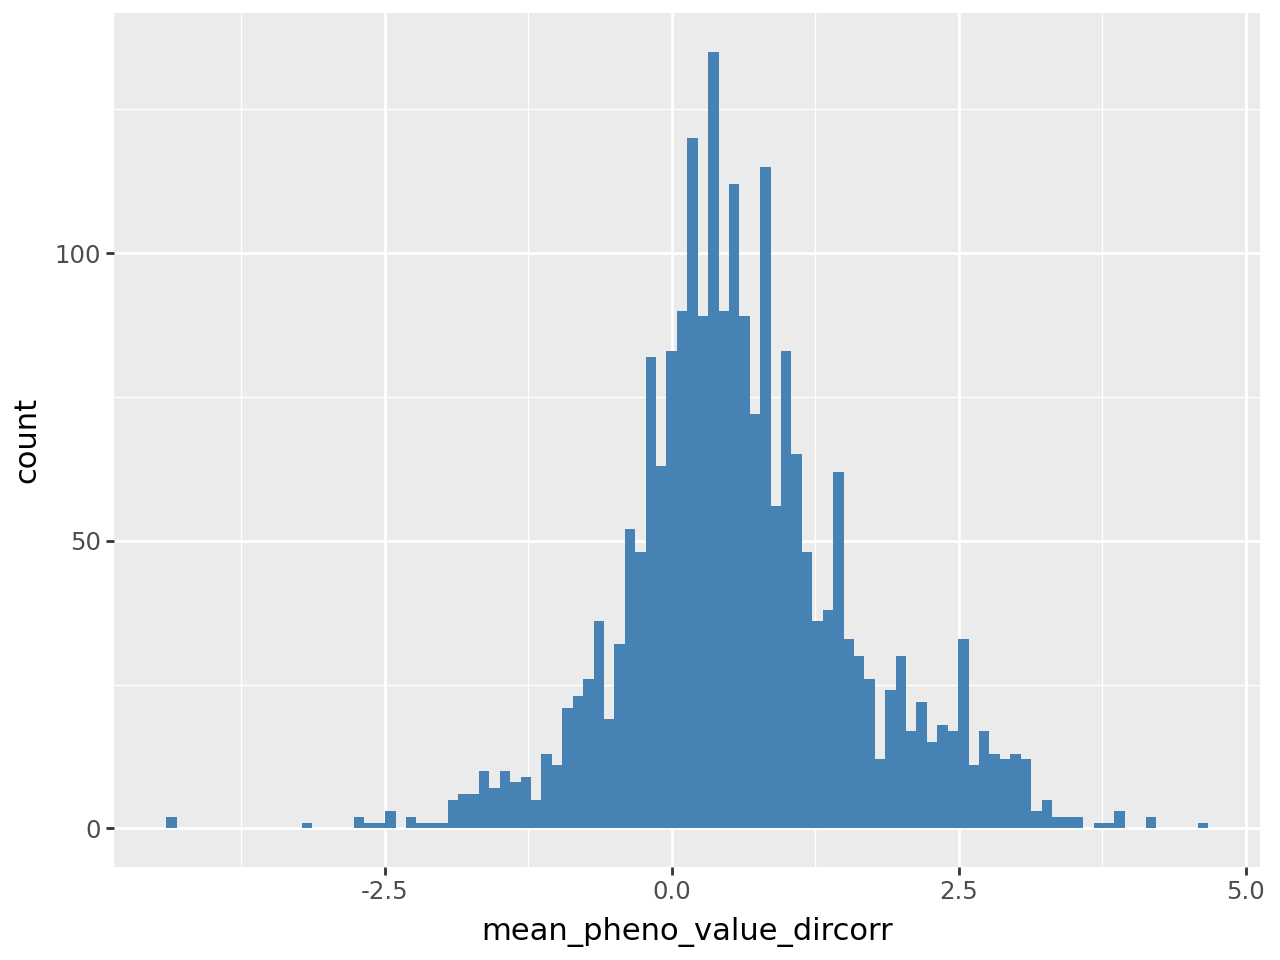

In [17]:
(
    ggplot(
        anno_pheno.filter(pl.col('clinical_significance')=='Pathogenic'), 
        aes(x='mean_pheno_value_dircorr')
    )
    + geom_histogram(bins=100, fill='steelblue') 
)

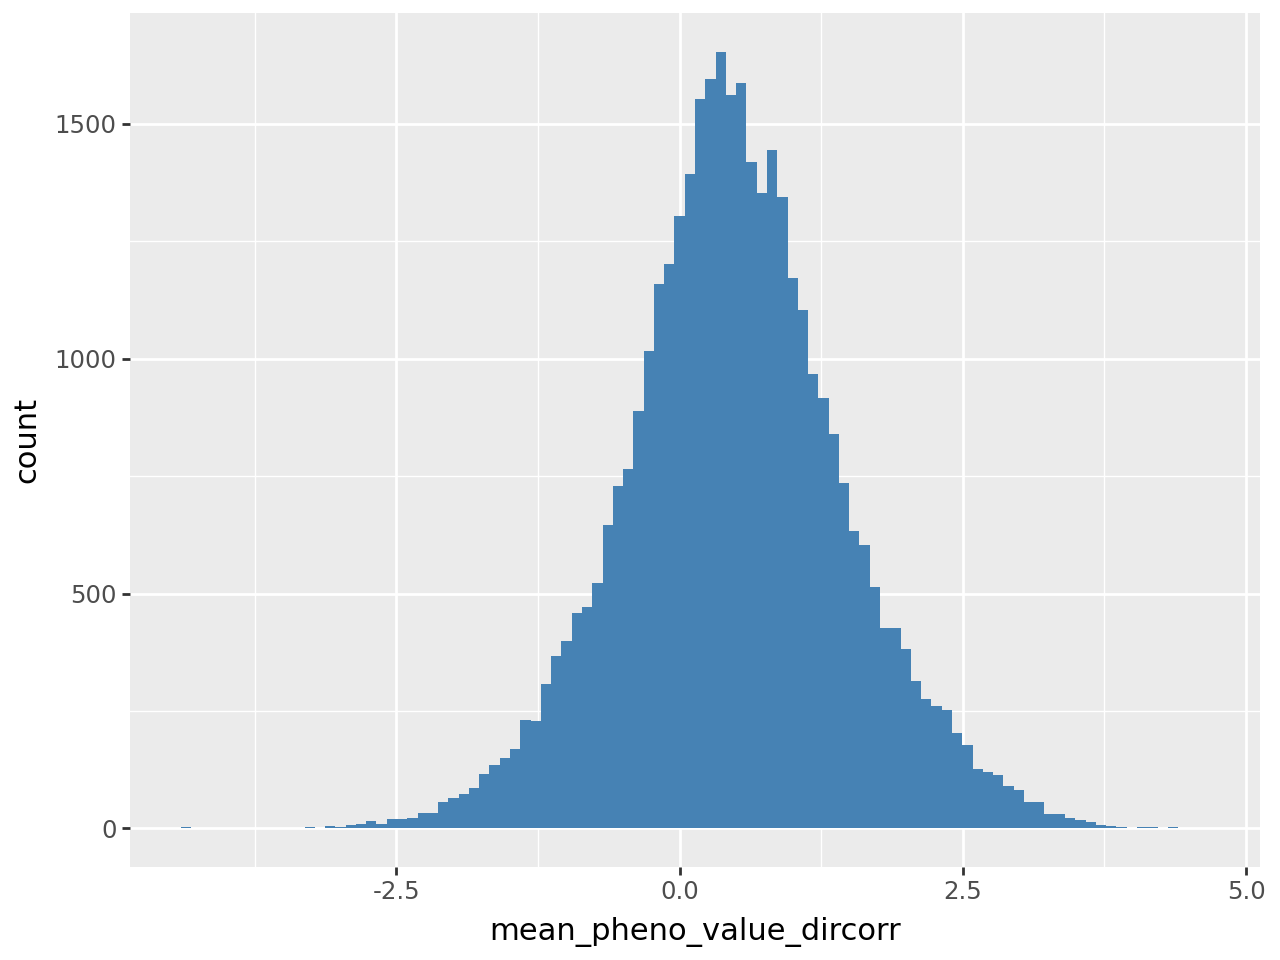

In [18]:
(
    ggplot(
        anno_pheno.filter(pl.col('loftee_hc')==1), 
        aes(x='mean_pheno_value_dircorr')
    )
    + geom_histogram(bins=100, fill='steelblue') 
)